# Fitting Demo Notebook

This notebook demonstrates the `PhysComp.fitting` module, which fits a two-component periodic model.

### Functions covered:
- `fitting.periodic` — model function
- `fitting.periodic_fit` — fit a single signal
- `fitting.periodic_fit_whole` — fit an entire 3D dataset pixel-by-pixel

## Needed Imports

The following imports are needed for this notebook. The prerequisites for the fitting module are tqdm and numpy, the others are only needed for the notebook to run.

In [1]:
## Required imports for functions
from tqdm import tqdm
import numpy as np

## Import for plotting within the notebook
import matplotlib.pyplot as plt

## Simulation function import for simulated data
import PhysComp.sim as sim

## Actual fitting import for functions
import PhysComp.fitting as fit

## Functions

This section covers the actual uses of the functions alongside some explanation of the methods with visualisation of the results.

### fitting.periodic

The periodic function produces a two component perodic model for a given position x and parameters in form [$A_1$,$\phi_1$,$A_2$,$\phi_2$,$C$] :

**f(x) = $A_1$ sin (x + $\phi_1$) + $A_2$ sin(2x + $\phi_2$) + C.**

Where $A_1$ and $A_2$ are the amplitudes of the one-fold and two-fold sin terms, respectively. $\phi_1$ and $\phi_2$ are the phase offsets of the one-fold and two-fold sin terms, respectively. C is the vertical offset of the signal. x is the angle in degrees, which is converted to radians for compatibility with the NumPy functions.

This model was chosen empirically for this project and is not the only suitable function, however it does fit the dataset used through this project.

The function takes inputs in the order [X$A_1$,$\phi_1$,$A_2$,$\phi_2$,$C$], where X is the independent variable (in degrees) for plotting and the other variables are as previously defined. A simple example is provided below in Figure 1 using an array of generic x values ranging up to 360 and arbitrarily chosen parameter values. 

#### Docstring

"""Evaluate a two-component periodic model at position(s) x.
    The model is the sum of two sine harmonics plus a vertical offset:

        f(x) = a * sin(x + b) + c * sin(2*(x + d)) + e

    where all angle arguments are converted from degrees to radians
    before evaluation.

    Parameters
    ----------
    x : array-like
        Input position(s) in degrees.
    a : float
        Amplitude of the sin(x) term.
    b : float
        Phase offset of the sin(x) term, in degrees.
    c : float
        Amplitude of the sin(2x) term.
    d : float
        Phase offset of the sin(2x) term, in degrees.
    e : float
        Vertical offset.

    Returns
    -------
    numpy.ndarray
        Model values at each point in *x*."""

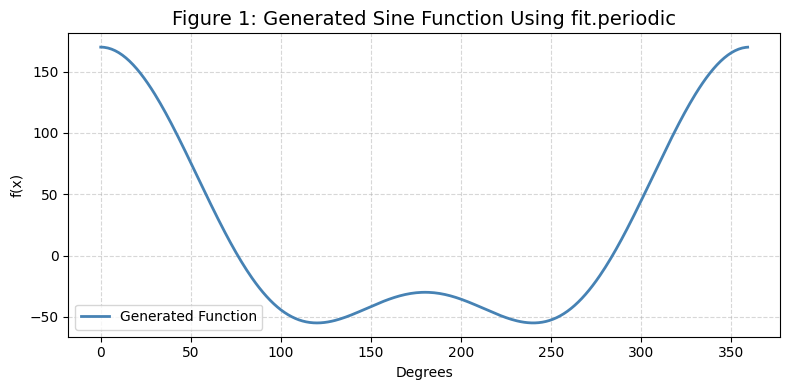

In [2]:
X = np.arange(360)                  # Generating x values
Params = [100, 90, 50, 45, 20]      # Arbitrary parameter values
fx = fit.periodic(X, *Params)           # Storing y values of function

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(X, fx, color="steelblue", linewidth=2, label="Generated Function")

ax.set_title("Figure 1: Generated Sine Function Using fit.periodic", fontsize=14)
ax.set_xlabel("Degrees")
ax.set_ylabel("f(x)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### fitting.periodic_fit

The periodic_fit function uses curve_fit to fit the periodic function for a given dataset. It returns an array of parameters and separately an array of associated errors in forms: [$A_1$,$\phi_1$,$A_2$,$\phi_2$,$C$] , [$\sigma_{A_1}$,$\sigma_{\phi_1}$,$\sigma_{A_2}$,$\sigma_{\phi_2}$,$\sigma_{C}$].

Initial guesses and bounds can be provided, but we will use the default arguments of asymmetric bounds around 0, which worked for the dataset within the project. Bounds are required to ensure sensible, physical solutions. This was developed through the project, which previously did unbounded calculations, resulting in nonsensical solutions. 

An example is provided below, where the function is fitted to a simulated dataset (See Sim demo notebook for more information). The result is shown in Figure 2:

#### Docstring

 """Fit the periodic model to data via curve_fit.

    Uses scipy.optimize.curve_fit to find best-fit parameters [a, b, c, d, e]
    for the model: f(x) = a*sin(x + b) + c*sin(2*(x + d)) + e

    Parameters
    ----------
    x_variable : array-like of shape (N,)
        Independent variable (in degrees). Requires at least 5 points.
    y_variable : array-like of shape (N,)
        Dependent variable. Must be the same length as x_variable.
    initial : list of 5 floats, optional
        Initial parameter guesses [a, b, c, d, e]. Defaults to [30, 5, 5, 0, 70].
    bounds : optional
        Lower and upper bounds per parameter:
        Defaults to ([0, -180, 0, -90, 0], [1e6, 180, 1e6, 90, 1e6]).

    Returns
    -------
    params : numpy.ndarray of shape (5,)
        Best-fit parameters [a, b, c, d, e].
    errors : numpy.ndarray of shape (5,)
        One-sigma uncertainties derived from the covariance matrix diagonal."""

A1: 84.90 ± 7.27
φ1: 37.33 ± 4.90
A2: 82.33 ± 7.27
φ2: -76.02 ± 2.53
C: 260.02 ± 5.14


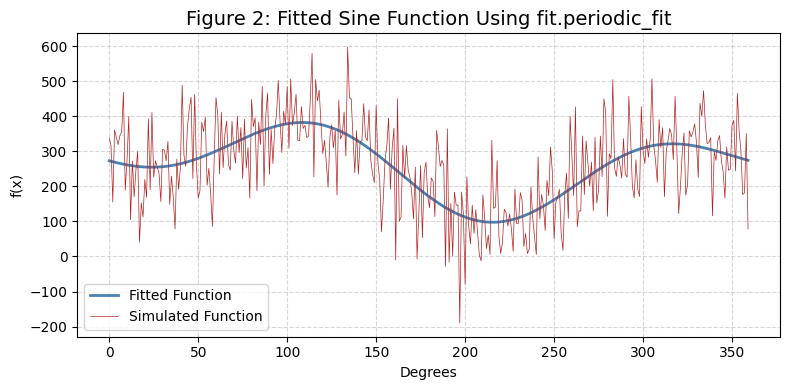

In [12]:
simulated_data = sim.sim_dataset(10,10,360,100,100, filesave= False, seed=100) # Simulating data, see Sim notebook for details

p0 = [1,1,1,1,1] # Inital Guesses
b0 = ([0,-180,0,-90,0],[1000,180,1000,90,1000]) # Bounds
X = np.arange(360)                  # Generating x values


## Using periodic_fit and unpacking params and errors
params, errors = fit.periodic_fit(X, simulated_data[0][0,0], initial = p0,bounds = b0) 

print(f"A1: {params[0]:.2f} ± {errors[0]:.2f}")
print(f"φ1: {params[1]:.2f} ± {errors[1]:.2f}")
print(f"A2: {params[2]:.2f} ± {errors[2]:.2f}")
print(f"φ2: {params[3]:.2f} ± {errors[3]:.2f}")
print(f"C: {params[4]:.2f} ± {errors[4]:.2f}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(X, fit.periodic(X, *params), color="steelblue", linewidth=2, label="Fitted Function")
ax.plot(X, simulated_data[0][0,0], color="firebrick", linewidth=0.5, label="Simulated Function")

ax.set_title("Figure 2: Fitted Sine Function Using fit.periodic_fit", fontsize=14)
ax.set_xlabel("Degrees")
ax.set_ylabel("f(x)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### fitting.periodic_fit_whole

Finally, the periodic_fit_whole function iterates the periodic_fit function over each pixel in a dataset. This requires a 3-D dataset with the first two dimensions being spatial and a third spectral or temporal dimension.

Iterative fitting is available, where the parameters from the previous pixel are the guesses for the next. This reduces computation time by ~30% on average, but may vary depending on the dataset. This may not improve computation time when parameters for each pixel are unrelated or different for adjacent pixels. 

Returns two arrays of shape (nx,ny,5) representing the params and errors for each pixel.

An example run through on a simulated dataset (See Sim demo notebook for more information) is shown below, with visualizations of the parameter and error map for amplitude 1 is shown as an example in in Figure 3, with a single pixel signal shown in Figure 4.  


#### Docstring

"""Fit the periodic model to every pixel in a 3-D dataset.

    Iterates over all (x, y) spatial pixels in dataset, fits
    'periodic` to the angular profile at each pixel using 'perodic_fit'.

    Parameters
    ----------
    dataset : numpy.ndarray of shape (nx, ny, nz)
        3-D array where the first two axes are spatial and the third axis
        contains the angular intensity profile sampled at evenly-spaced
        degrees equal to 'degrees'.
    initial : list of 5 floats
        Initial parameter guesses [a, b, c, d, e] for the first fit.
        When iterative_fitting is True, subsequent pixels reuse the
        previous pixel's best-fit parameters as the new initial guess.
    bounds : 2-tuple of sequences, optional
        Parameter bounds passed directly to :func:`periodic_fit`.
        See that function for the expected format.
    iterative_fitting : bool, optional
        If True, the best-fit parameters from each pixel are used as the
        initial guess for the next, improves computational time needed by ~30%.

    Returns
    -------
    params_reshaped : numpy.ndarray of shape (nx, ny, 5)
        Best-fit parameters [a, b, c, d, e] for every pixel.
    errors_reshaped : numpy.ndarray of shape (nx, ny, 5)
        Corresponding one-sigma uncertainties for every pixel.
    """

In [6]:
simulated_dataset = sim.sim_dataset(50,50,360,100,100, filesave= False, seed=100) # Simulating data, see Sim notebook

p0 = [1,1,1,1,1] # Inital Guesses
b0 = ([0,-180,0,-90,0],[1000,180,1000,90,1000]) # Bounds

## Using periodic_fit and unpacking params and errors
params, errors = fit.periodic_fit_whole(simulated_dataset[0], p0, bounds =b0) 

Processing slices: 100%|██████████| 2500/2500 [00:30<00:00, 82.12it/s]


In [7]:
simulated_dataset = sim.sim_dataset(50,50,360,100,100, filesave= False, seed=100) # Simulating data, see Sim notebook

p0 = [1,1,1,1,1] # Inital Guesses
b0 = ([0,-180,0,-90,0],[1000,180,1000,90,1000]) # Bounds

## Using periodic_fit and unpacking params and errors
params, errors = fit.periodic_fit_whole(simulated_dataset[0], p0, bounds =b0,iterative_fitting=True) ## Iterative fitting reduces time

Processing slices: 100%|██████████| 2500/2500 [00:15<00:00, 157.73it/s]


In [8]:
### Accessing params maps
A1_map = params[:,:,0]
phi1_map = params[:,:,1]
A2_map = params[:,:,2]
phi2_map = params[:,:,3]
offset_map = params[:,:,4]

### Accessing errors maps
A1_err_map = errors[:,:,0]
phi1_err_map = errors[:,:,1]
A2_err_map = errors[:,:,2]
phi2_err_map = errors[:,:,3]
offset_err_map = errors[:,:,4]

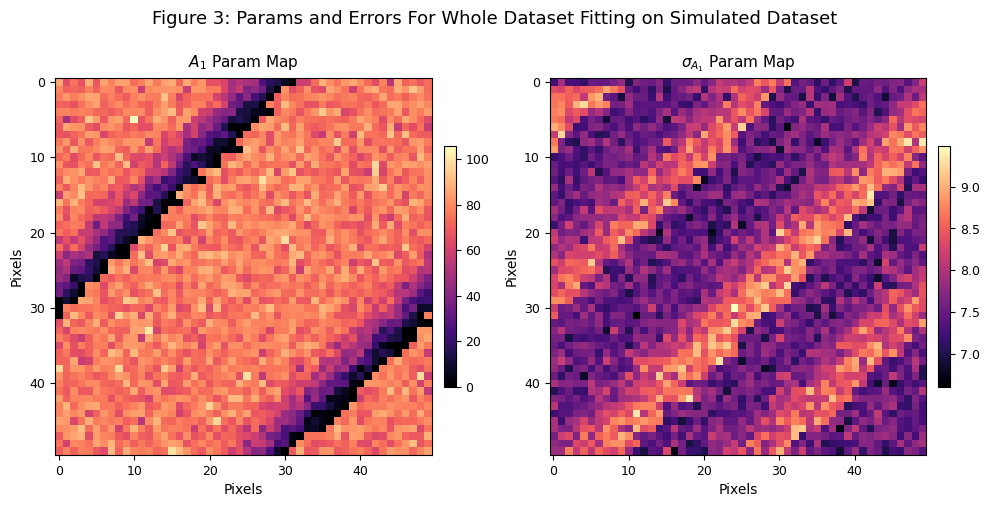

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))

im0 = axes[0].imshow(A1_map, cmap="magma")

plt.suptitle("Figure 3: Params and Errors For Whole Dataset Fitting on Simulated Dataset", fontsize=13,y=0.9)

axes[0].set_title("$A_1$ Param Map", fontsize=11, pad=8)

im1 = axes[1].imshow(A1_err_map, cmap="magma")
axes[1].set_title("$\sigma_{A_1}$ Param Map", fontsize=11, pad=8)

for ax in axes:
    ax.set_xlabel("Pixels", fontsize=10)
    ax.set_ylabel("Pixels", fontsize=10)
    ax.tick_params(labelsize=9)

cb0 = fig.colorbar(im0, ax=axes[0], fraction=0.03, pad=0.03)
cb1 = fig.colorbar(im1, ax=axes[1], fraction=0.03, pad=0.03)
cb0.ax.tick_params(labelsize=9)
cb1.ax.tick_params(labelsize=9)

plt.tight_layout()

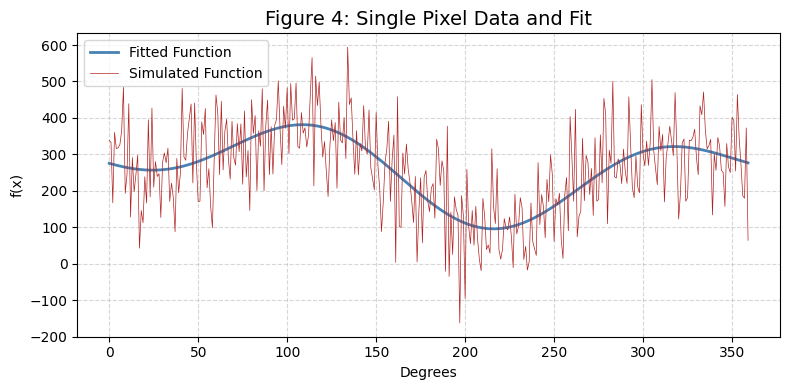

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(X, fit.periodic(X, *params[0,0,:]), color="steelblue", linewidth=2, label="Fitted Function")
ax.plot(X, simulated_dataset[0][0,0], color="firebrick", linewidth=0.5, label="Simulated Function")

ax.set_title("Figure 4: Single Pixel Data and Fit", fontsize=14)
ax.set_xlabel("Degrees")
ax.set_ylabel("f(x)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()